In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact
import warnings
warnings.filterwarnings('ignore')
# Charger le fichier Excel
df =pd.read_excel(
    r"C:\Users\home\Desktop\DI-Bootcamp\Week2\Day5\DayChallenge\US Superstore data.xls"
)
# Aperçu des données
print("Dimensions :", df.shape)
print("\nColonnes :")
print(df.columns)
df.head()

Dimensions : (9994, 21)

Colonnes :
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='str')


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# Vérification des valeurs manquantes
print(df.isnull().sum())
# Suppression des doublons
df = df.drop_duplicates()
# Conversion des dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
# Création de variables temporelles
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
print(df.info())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null

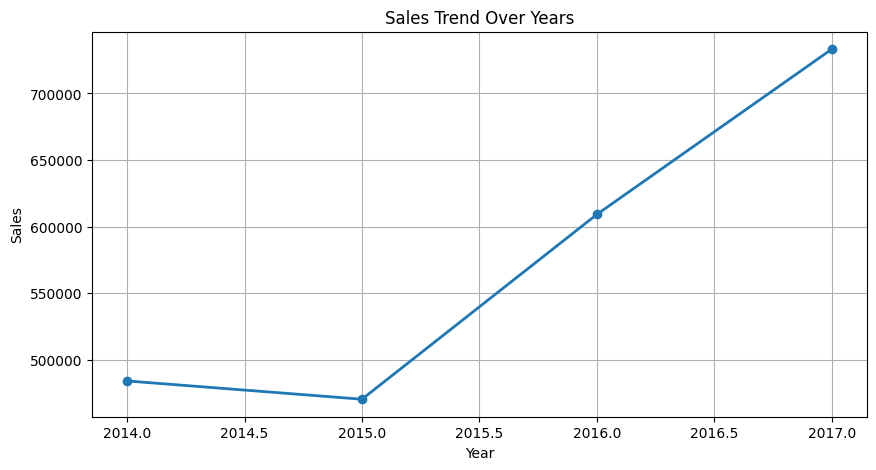

In [7]:
sales_year = df.groupby('Year')['Sales'].sum()
def sales_trend():
    plt.figure(figsize=(10,5))
    plt.plot(sales_year.index,
             sales_year.values,
             marker='o',
             linewidth=2)
    plt.title('Sales Trend Over Years')
    plt.xlabel('Year')
    plt.ylabel('Sales')
    plt.grid(True)
    plt.show()
sales_trend()

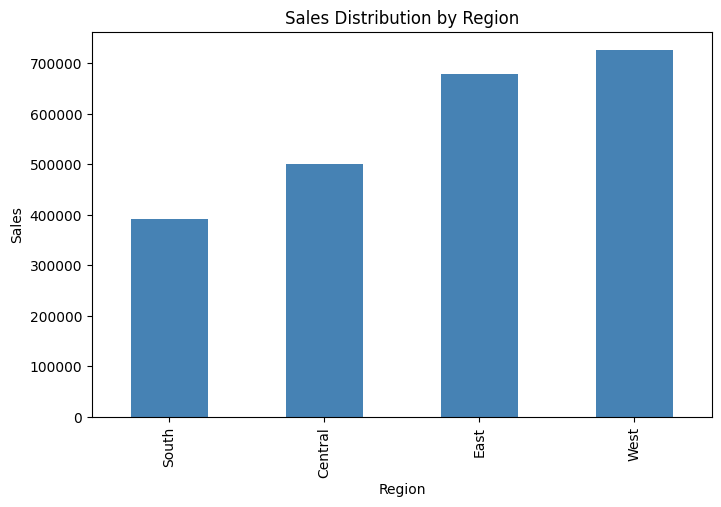

In [8]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()
plt.figure(figsize=(8,5))
region_sales.plot(
    kind='bar',
    color='steelblue'
)
plt.title('Sales Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.show()

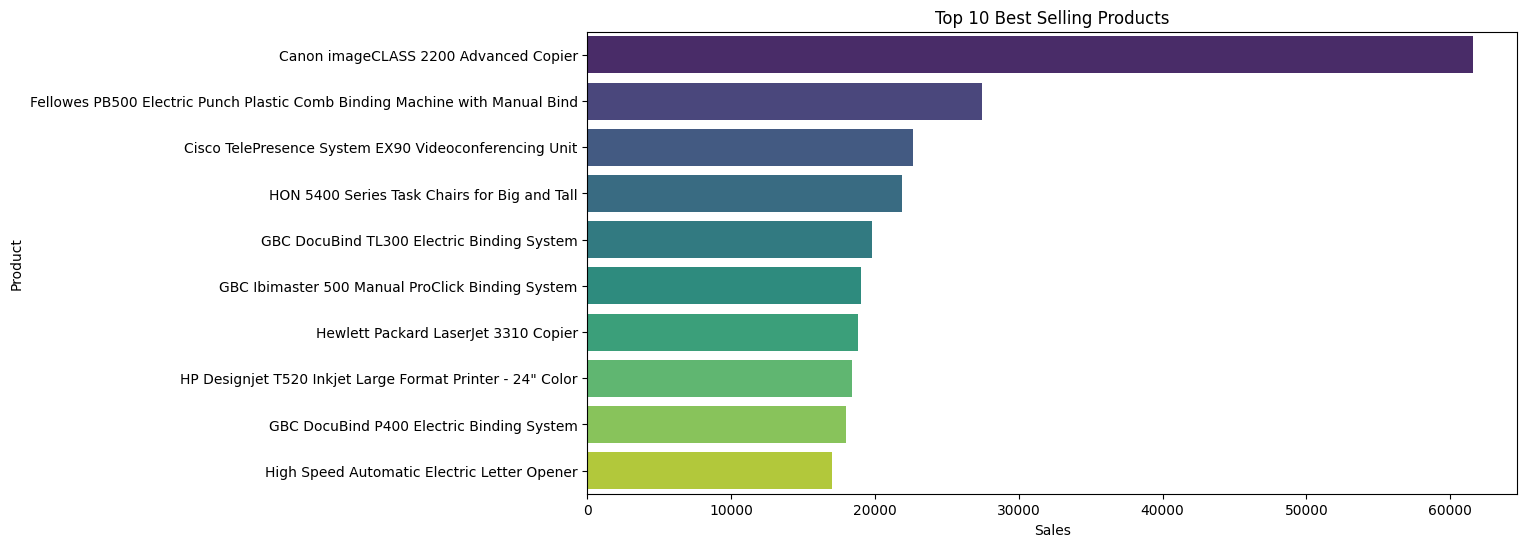

In [9]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
plt.figure(figsize=(12,6))
sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='viridis'
)
plt.title('Top 10 Best Selling Products')
plt.xlabel('Sales')
plt.ylabel('Product')
plt.show()

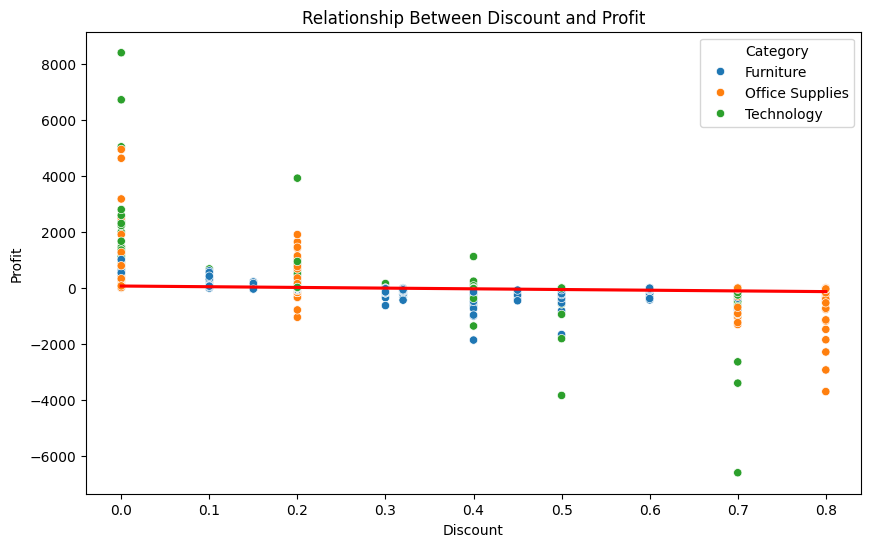

In [10]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='Discount',
    y='Profit',
    hue='Category'
)
sns.regplot(
    data=df,
    x='Discount',
    y='Profit',
    scatter=False,
    color='red'
)
plt.title('Relationship Between Discount and Profit')
plt.show()

# Comparative Analysis: Matplotlib vs Seaborn
## Matplotlib
- Highly customizable.
- Better for interactive and complex visualizations.
- Provides full control over chart elements.
## Seaborn
- Easier to use.
- Produces attractive visualizations with less code.
- Excellent for statistical analysis.
## Observations
- Matplotlib was useful for displaying sales trends over time.
- Seaborn made it easier to analyze product performance and the relationship between profit and discount.
- Both libraries complement each other in data analysis projects.

In [4]:
import sys
print(sys.executable)

c:\Users\home\Desktop\DI-Bootcamp\env\Scripts\python.exe
